In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

In [2]:
df= pd.read_csv(r"C:\Users\GOURI\OneDrive\Desktop\DATASETS\shop_smart_ecommerce.csv")
df.head(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


In [3]:
df.shape

(12330, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df["Revenue"].value_counts()    

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [6]:
df["Month"].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [7]:
month_order = [["Feb", "Mar", "May", "June", "Jul",
                "Aug", "Sep", "Oct", "Nov", "Dec"]]

if df["Month"].dtype == "object":
    oe = OrdinalEncoder(categories=month_order)
    df["Month"] = oe.fit_transform(df[["Month"]]).astype(int) + 1  

df.sample(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
1268,0,0.0,3,56.0,10,369.000000,0.0,0.016667,0.000000,0.0,2,1,1,4,2,New_Visitor,True,False
10337,0,0.0,0,0.0,4,0.000000,0.2,0.200000,0.000000,0.0,9,3,2,1,3,Returning_Visitor,False,False
8092,3,123.5,1,0.0,22,759.583333,0.0,0.009600,46.678528,0.0,9,1,1,3,2,Returning_Visitor,False,True


In [8]:
df= pd.get_dummies(df, columns= ["VisitorType"], drop_first= True, dtype= int)
df.sample(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
9145,0,0.0,0,0.0,11,332.291667,0.000000,0.009091,0.0000,0.0,10,2,2,2,2,False,False,0,1
3334,2,98.0,0,0.0,44,2279.222222,0.001111,0.012302,7.0182,0.0,3,3,2,7,4,False,False,0,1
10009,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0000,0.0,9,2,2,6,10,False,False,0,1


In [9]:
df["Revenue"]= df["Revenue"].astype(int)
df.sample(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
9388,0,0.0,0,0.0,10,130.750000,0.040000,0.076667,0.0,0.0,9,3,2,1,3,False,0,0,1
4613,3,334.6,0,0.0,20,1201.600000,0.011111,0.022222,0.0,0.2,3,3,2,1,13,False,0,0,1
5871,2,11.0,0,0.0,59,779.262857,0.000000,0.007471,0.0,0.0,6,4,1,1,4,False,0,0,1


In [10]:
df["Weekend"]= df["Weekend"].astype(int)
df.sample(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
168,0,0.0,0,0.0,11,684.333333,0.018182,0.063636,0.0,0.0,1,2,4,6,1,0,0,0,1
10084,2,67.5,0,0.0,7,393.500000,0.000000,0.025000,0.0,0.0,10,2,2,1,2,0,0,0,0
4491,3,48.0,0,0.0,10,129.500000,0.000000,0.018182,0.0,0.0,3,2,5,9,4,0,0,0,1


In [11]:
df.shape

(12330, 19)

In [12]:
X= df.drop(columns= ["Revenue"])
y= df["Revenue"]

X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size= 0.2, random_state= 42
)

In [13]:
param_grid = {
    "max_depth": range(2, 15),
    "min_samples_leaf": [5, 10, 15, 20, 25, 30]
}

In [14]:
dt = DecisionTreeClassifier(
    class_weight="balanced",   
    random_state=42
)

In [15]:
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1",   
    n_jobs=-1   
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': range(2, 15),
                         'min_samples_leaf': [5, 10, 15, 20, 25, 30]},
             scoring='f1')

In [16]:
best_model = grid.best_estimator_
best_model

DecisionTreeClassifier(class_weight='balanced', max_depth=2, min_samples_leaf=5,
                       random_state=42)

In [17]:
print("Best Parameters:", grid.best_params_) 
print("Best F1 Score:", grid.best_score_)  

Best Parameters: {'max_depth': 2, 'min_samples_leaf': 5}
Best F1 Score: 0.6599842366229802


In [19]:
y_train_pred= best_model.predict(X_train)   
y_test_pred= best_model.predict(X_test)


print("Train F1 Score: ", f1_score(y_train, y_train_pred))
print("Test F1 Score: ", f1_score(y_test, y_test_pred))

print("Classification Report: ", classification_report(y_test, y_test_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_test_pred))

Train F1 Score:  0.6599234554401312
Test F1 Score:  0.676200204290092
Classification Report:                precision    recall  f1-score   support

           0       0.96      0.88      0.92      2055
           1       0.58      0.81      0.68       411

    accuracy                           0.87      2466
   macro avg       0.77      0.85      0.80      2466
weighted avg       0.90      0.87      0.88      2466

Confusion Matrix:  [[1818  237]
 [  80  331]]


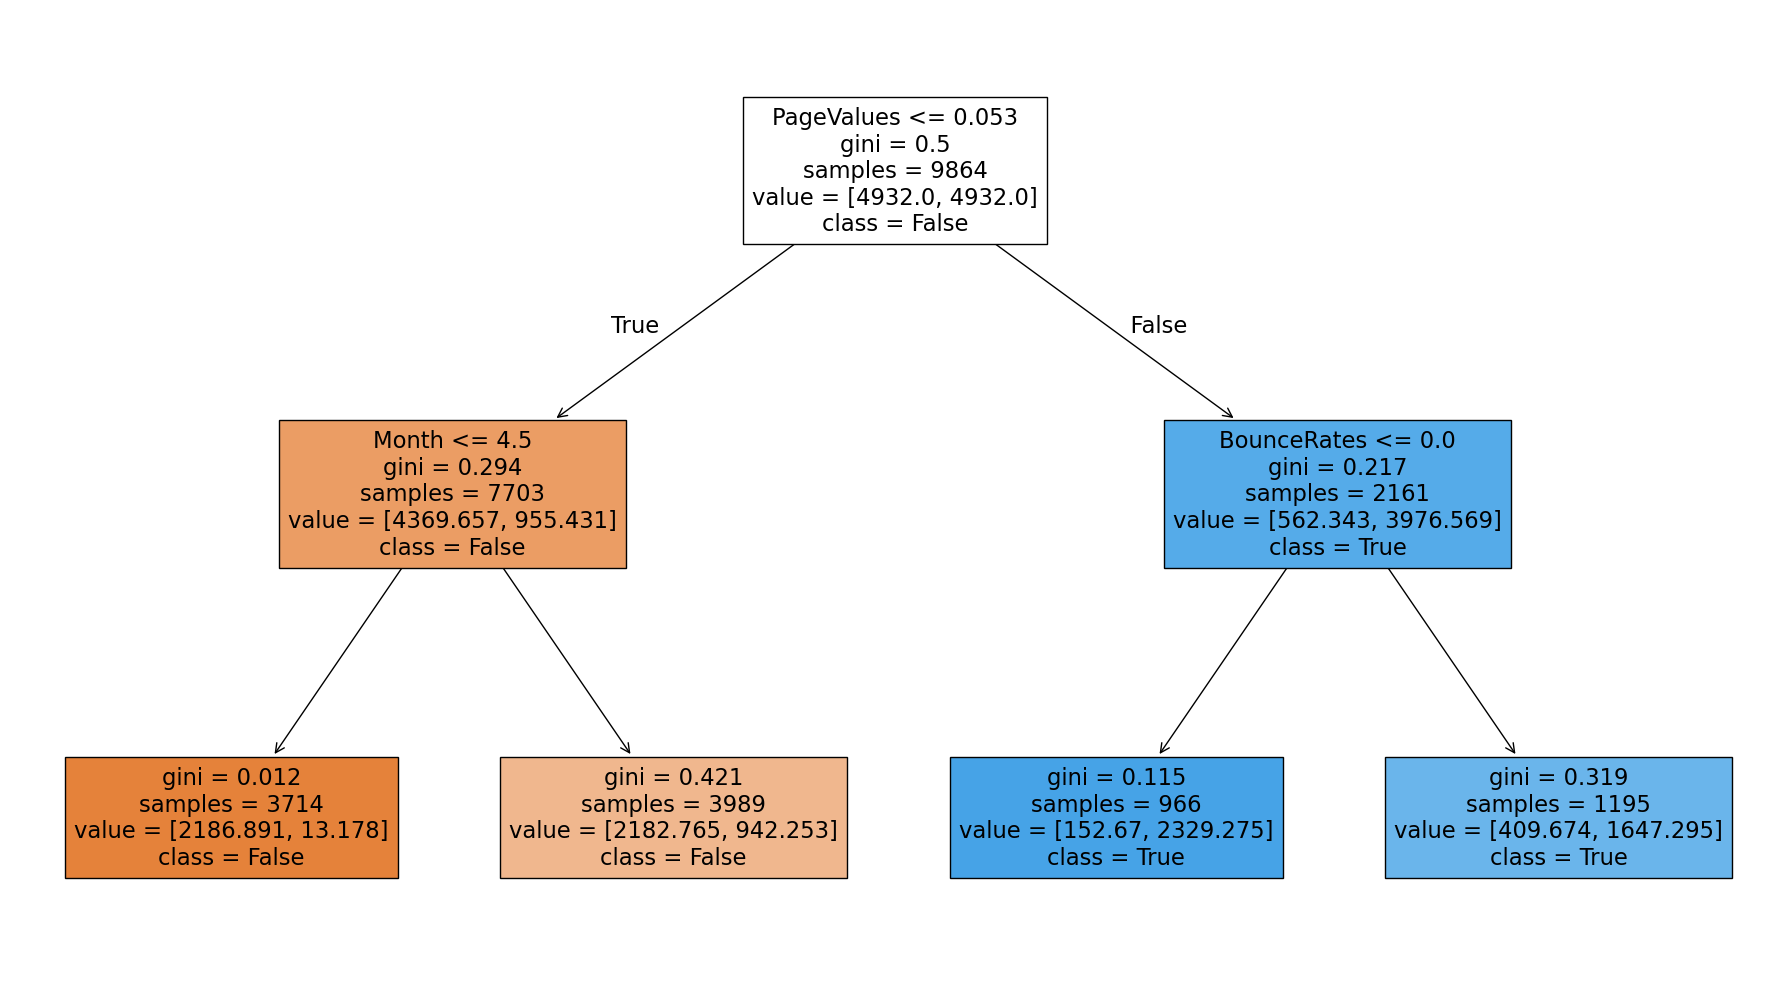

In [26]:
plt.figure(figsize= (18, 10))
plot_tree(
grid.best_estimator_,
feature_names= X.columns,
class_names= ["False", "True"],
filled= True,
max_depth= 3    
)

plt.tight_layout()
plt.show()